## Generative Adversarial Networks (GAN) - DCGANs

In [ ]:
# Import time for measuring training duration
import time
# Import numpy for numerical operations
import numpy as np
from __future__ import print_function

In [ ]:
# Import PyTorch core modules and neural network utilities
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init
import torch.nn.functional as F
from torch.autograd import Variable # For automatic differentiation

In [ ]:
# Import torchvision for datasets and image transformations
import torchvision
import torchvision.transforms

In [ ]:
# Import matplotlib for plotting images and results
import matplotlib.pyplot as plt
# Enable inline plotting in Jupyter notebooks
%matplotlib inline

### Define image transformations &  Initialize datasets

In [ ]:
# Define transformation to convert images to tensors
mnist_transforms = torchvision.transforms.Compose([torchvision.transforms.ToTensor()])
# Load MNIST training dataset with the defined transform
mnist_train = torchvision.datasets.MNIST(root='./data', train=True, transform=mnist_transforms, download=True)

In [ ]:
# Create DataLoader for efficient batch processing and shuffling
trainloader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True, num_workers=2)

### Create DCGAN Generator

![caption](images/dcgan_g.png)


      (deconv1): ConvTranspose2d(128, 128, kernel_size=(4, 4), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True)

      (deconv2): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True)

      (deconv3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (bn3): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True)

      (deconv4): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(3, 3), bias=False)


In [ ]:
# Define the DCGAN Generator network
class Generator(nn.Module):
    """DCGAN Generator."""
    def __init__(self, z_dim=128, num_filters=32):
        super(Generator, self).__init__()
        self.z_dim = z_dim
        self.num_filters = num_filters
        # 1 x 1 -> 4 x 4
        self.deconv1 = nn.ConvTranspose2d(
            in_channels=z_dim, out_channels=num_filters * 4,
            kernel_size=(4, 4), bias=False
        )
        self.bn1 = nn.BatchNorm2d(num_filters * 4)
        # 4 x 4 -> 8 x 8
        self.deconv2 = nn.ConvTranspose2d(
            in_channels=num_filters * 4, out_channels=num_filters * 2,
            kernel_size=(4, 4), stride=2, padding=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(num_filters * 2)
        # 8 x 8 -> 16 x 16
        self.deconv3 = nn.ConvTranspose2d(
            in_channels=num_filters * 2, out_channels=num_filters,
            kernel_size=(4, 4), stride=2, padding=1, bias=False,
        )
        self.bn3 = nn.BatchNorm2d(num_filters)
        # 16 x 16 -> 28 x 28
        self.deconv4 = nn.ConvTranspose2d(
            in_channels=num_filters, out_channels=1,
            kernel_size=(4, 4), stride=2, padding=3, bias=False,
        )
        
    def forward(self, x):
        # Pass through deconvolutional and batchnorm layers with ReLU activations
        x = F.relu(self.bn1(self.deconv1(x)))
        x = F.relu(self.bn2(self.deconv2(x)))
        x = F.relu(self.bn3(self.deconv3(x)))
        # Final layer uses tanh activation to output image
        return F.tanh(self.deconv4(x))

### Create DCGAN Discriminator

![caption](images/dcgan_d.png)

    
    (conv1): Conv2d(1, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True)
    
    (conv2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True)
    
    (conv3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True)
    
    (conv4): Conv2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)


In [ ]:
# Define the DCGAN Discriminator network
class Discriminator(nn.Module):
    """DCGAN Discriminator."""
    def __init__(self, num_filters=32):
        super(Discriminator, self).__init__()
        self.num_filters = num_filters
        # 28 x 28 -> 14 x 14
        self.conv1 = nn.Conv2d(
            in_channels=1, out_channels=num_filters,
            kernel_size=(4, 4), stride=2, padding=1, bias=False
        )
        self.bn1 = nn.BatchNorm2d(num_filters)
        # 14 x 14 -> 7 x 7
        self.conv2 = nn.Conv2d(
            in_channels=num_filters, out_channels=num_filters * 2,
            kernel_size=(4, 4), stride=2, padding=1, bias=False,
        )
        self.bn2 = nn.BatchNorm2d(num_filters * 2)
        # 7 x 7 -> 3 x 3
        self.conv3 = nn.Conv2d(
            in_channels=num_filters * 2, out_channels=num_filters * 4,
            kernel_size=(4, 4), stride=2, padding=1, bias=False,
        )
        self.bn3 = nn.BatchNorm2d(num_filters * 4)
        # 3 x 3 -> 1 x 1
        self.conv4 = nn.Conv2d(
            in_channels=num_filters * 4, out_channels=1,
            kernel_size=(4, 4), stride=2, padding=1, bias=False,
        )

    def forward(self, x):
        # Pass through convolutional and batchnorm layers with LeakyReLU activations
        x = F.leaky_relu(self.bn1(self.conv1(x)), 0.2)
        x = F.leaky_relu(self.bn2(self.conv2(x)), 0.2)
        x = F.leaky_relu(self.bn3(self.conv3(x)), 0.2)
        # Final layer uses sigmoid activation to output probability
        return F.sigmoid(self.conv4(x)).squeeze()

In [ ]:
# Check if CUDA (GPU) is available for faster training
cuda_available = torch.cuda.is_available()

### Initialize Generator & Discriminator

In [ ]:
# Instantiate generator and discriminator, move to GPU if available
generator = Generator()
discriminator = Discriminator()
if cuda_available:
    generator = generator.cuda()
    discriminator = discriminator.cuda()
# Set up loss function and optimizers for both networks
loss = nn.BCELoss()
optimizer_g = torch.optim.Adam(generator.parameters(), lr=2e-4)
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=2e-4)

### Training Loop

In [ ]:
# Training loop for DCGAN: alternately update discriminator and generator
ctr = 0
z_dim = 128
# Track losses for monitoring
minibatch_disc_losses = []
minibatch_gen_losses = []

for epoch in range(50):
    losses = []
    # Train
    for batch_idx, (inputs, targets) in enumerate(trainloader):
        ctr += 1
        if cuda_available:
            inputs, targets = inputs.cuda(), targets.cuda()
        # Wrap inputs and targets in Variables
        inputs, targets = Variable(inputs), Variable(targets)
        # Create label tensors for real and fake samples
        zeros = Variable(torch.zeros(inputs.size(0)))
        ones = Variable(torch.ones(inputs.size(0)))
        if cuda_available:
            zeros, ones = zeros.cuda(), ones.cuda()
        ############################
        # (1) Update Discriminator 
        ############################
        
        # Sample z ~ N(0, 1)
        minibatch_noise = Variable(torch.from_numpy(
            np.random.randn(inputs.size(0), z_dim, 1, 1).astype(np.float32)
        ))
        if cuda_available:
            minibatch_noise = minibatch_noise.cuda()
        
        # Zero gradients for the discriminator
        optimizer_d.zero_grad()
        
        # Train with real examples
        d_real = discriminator(inputs)

        d_real_loss = loss(d_real, ones)  # Train discriminator to recognize real examples
        d_real_loss.backward()
        
        # Train with fake examples from the generator
        fake = generator(minibatch_noise).detach()  # Detach to prevent backpropping through the generator
        d_fake = discriminator(fake)

        d_fake_loss = loss(d_fake, zeros)  # Train discriminator to recognize generator samples
        d_fake_loss.backward()
        minibatch_disc_losses.append(d_real_loss.data[0] + d_fake_loss.data[0])
        
        # Update the discriminator
        optimizer_d.step()
        
        ############################
        # (2) Update Generator
        ############################
        # Zero gradients for the generator
        optimizer_g.zero_grad()
        
        # Sample z ~ N(0, 1)
        minibatch_noise = Variable(torch.from_numpy(
            np.random.randn(inputs.size(0), z_dim, 1, 1).astype(np.float32)
        ))

        if cuda_available:
            minibatch_noise = minibatch_noise.cuda()
            
        d_fake = discriminator(generator(minibatch_noise))
        g_loss = loss(d_fake, ones)  # Train generator to fool the discriminator into thinking these are real.
        g_loss.backward()
        # Update the generator
        optimizer_g.step()
        minibatch_gen_losses.append(g_loss.data[0])
    
    print('Generator loss : %.3f' % (np.mean(minibatch_gen_losses)))
    print('Discriminator loss : %.3f' % (np.mean(minibatch_disc_losses)))

Generator loss : 5.097
Discriminator loss : 0.067
Generator loss : 5.533
Discriminator loss : 0.050
Generator loss : 5.576
Discriminator loss : 0.056
Generator loss : 5.294
Discriminator loss : 0.078
Generator loss : 4.986
Discriminator loss : 0.106
Generator loss : 4.708
Discriminator loss : 0.138
Generator loss : 4.477
Discriminator loss : 0.164
Generator loss : 4.274
Discriminator loss : 0.191
Generator loss : 4.098
Discriminator loss : 0.213
Generator loss : 3.960
Discriminator loss : 0.230
Generator loss : 3.841
Discriminator loss : 0.246
Generator loss : 3.741
Discriminator loss : 0.259
Generator loss : 3.654
Discriminator loss : 0.271
Generator loss : 3.581
Discriminator loss : 0.281
Generator loss : 3.517
Discriminator loss : 0.288
Generator loss : 3.465
Discriminator loss : 0.294
Generator loss : 3.417
Discriminator loss : 0.300
Generator loss : 3.374
Discriminator loss : 0.306
Generator loss : 3.338
Discriminator loss : 0.310
Generator loss : 3.303
Discriminator loss : 0.315


Process Process-95:
  File "/home/sandeep/anaconda2/lib/python2.7/multiprocessing/process.py", line 258, in _bootstrap
Process Process-96:
Traceback (most recent call last):
Traceback (most recent call last):
  File "/home/sandeep/anaconda2/lib/python2.7/multiprocessing/process.py", line 258, in _bootstrap
    self.run()
    self.run()
  File "/home/sandeep/anaconda2/lib/python2.7/multiprocessing/process.py", line 114, in run
  File "/home/sandeep/anaconda2/lib/python2.7/multiprocessing/process.py", line 114, in run
    self._target(*self._args, **self._kwargs)
    self._target(*self._args, **self._kwargs)
  File "/home/sandeep/anaconda2/lib/python2.7/site-packages/torch/utils/data/dataloader.py", line 35, in _worker_loop
  File "/home/sandeep/anaconda2/lib/python2.7/site-packages/torch/utils/data/dataloader.py", line 35, in _worker_loop
    r = index_queue.get()
    r = index_queue.get()
  File "/home/sandeep/anaconda2/lib/python2.7/multiprocessing/queues.py", line 378, in get
  File 

KeyboardInterrupt: 

### Sample from the Generator

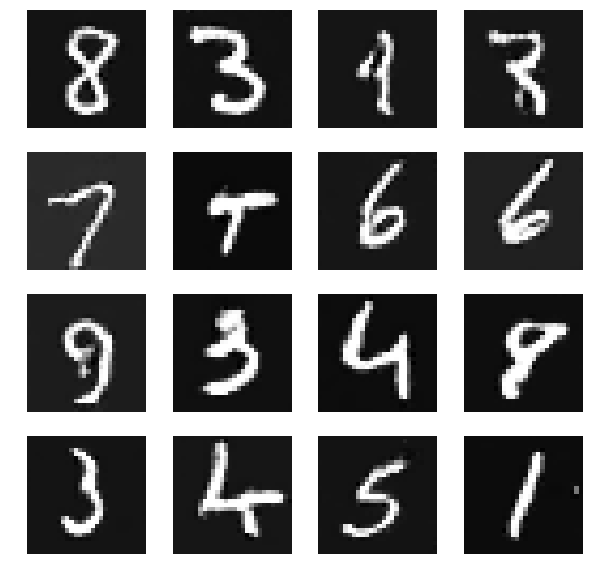

In [ ]:
# Sample images from the generator and visualize them
generator.eval() # Set generator in evaluation mode to use running means and averages for Batchnorm
# Sample z ~ N(0, 1) for generator input
minibatch_noise = Variable(torch.from_numpy(
    np.random.randn(16, z_dim, 1, 1).astype(np.float32)
))

if cuda_available:
    minibatch_noise = minibatch_noise.cuda()

fakes = generator(minibatch_noise)
# Plot generated images in a 4x4 grid
fig = plt.figure(figsize=(10, 10))
idx = 1
for ind, fake in enumerate(fakes):
    fig.add_subplot(4, 4, ind + 1)
    plt.imshow(fake.data.cpu().numpy().reshape(28, 28), cmap='gray')
    plt.axis('off')